# Prototype Fisher forecast with Alcock-Paczyński effect

We prototype a Fisher forecast using `jax.jacfwd` and a Gaussian covariance for $P^\ell_{\mathrm{1-loop}}(k)$ where $\ell=[0,2,4]$ for a single redshift bin, **including the Alcock-Paczyński (AP) effect**.

To connect a cosmological model to the observed power spectrum multipoles, we use [cosmopower-jax](https://github.com/dpiras/cosmopower-jax) to emulate the linear matter power spectrum and [ps_1loop_jax](https://github.com/archaeo-pteryx/ps_1loop_jax) to obtain the power spectrum multipoles.

The AP effect requires $H(z)$ and $D_A(z)$. We compute them analytically using `ps_1loop_jax.background`, which implements the flat $\nu$LCDM Friedmann equation in pure JAX and is fully differentiable via `jax.jacfwd`.

The AP distortion parameters are
$$
\alpha_\perp = \frac{D_A^\mathrm{true}(z)}{D_A^\mathrm{fid}(z)}, \qquad \alpha_\parallel = \frac{H^\mathrm{fid}(z)}{H^\mathrm{true}(z)},
$$
where all distances are in physical $\mathrm{Mpc}$ and $H$ in $\mathrm{km\,s^{-1}\,Mpc^{-1}}$.

## Modules

In [1]:
import os

### matplotlib

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern",
    "font.size": 22})

from matplotlib.ticker import MultipleLocator, FormatStrFormatter

### numpy

import numdifftools as nd
import numpy as np

### jax

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.scipy as jsp

### background cosmology

from ps_1loop_jax import background as bg

### jaxptpolypol

from jaxptpolypol.model import CosmoEmulator, PS1LoopModel
from jaxptpolypol.params import (
    CosmoParams,
    FullShapeSurveyParams,
    pack_pk_params,
    unpack_pk_params,
)
from jaxptpolypol.covariance import gaussian_covariance
from jaxptpolypol.inference import fisher_matrix, marginalize_fisher, sigma_from_fisher
from jaxptpolypol.plotting import plot_contours, plot_Gaussian, triangle_plot
from jaxptpolypol.theory import make_pk_ell_fn, compute_fiducial_distances

## Emulator and model classes

Basic classes for `cosmopower_jax.CosmoPowerJAX` emulator and `ps_1loop_jax.PowerSpectrum1Loop` model.

## Initialize emulators and model

We use model A (flat $\Lambda$CDM with baryon feedback) from [Jense et al. 2024](https://arxiv.org/abs/2306.10271).

In [2]:
model_path = '/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_Pk_lin.npz'

pklin_emulator = CosmoEmulator(probe='custom_log', emulator_path=model_path)
print("Emulator input parameters:", pklin_emulator.parameters)

ps1loop_model = PS1LoopModel(do_irres=True)
print("1-loop Pk terms:", ps1loop_model.pk_terms)

Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Emulator input parameters: ['ombh2' 'omch2' 'logA' 'ns' 'h' 'z' 'A_b' 'eta_b' 'logT_AGN']
1-loop Pk terms: ['22_dd', '13_dd', 'I_d2', 'I_G2', 'I_d2_d2', 'I_G2_G2', 'I_d2_G2', 'F_G2']


## Cosmology and survey parameter classes

## Fiducial cosmology and survey parameters

### Cosmological parameters

In [3]:
cosmo_dict = {
    'ombh2': 0.02242,
    'omch2': 0.11933,
    'logA':  3.047,
    'ns':    0.9665,
    'h':     0.6766,
    'z':     1.1,
    'A_b':   3.13,
    'eta_b': 0.603,
    'logT_AGN': 7.8
}
cosmo = CosmoParams(cosmo_dict)
print(cosmo)

CosmoParams:
  ombh2: 0.02242
  omch2: 0.11933
  logA: 3.047
  ns: 0.9665
  h: 0.6766
  z: 1.1
  A_b: 3.13
  eta_b: 0.603
  logT_AGN: 7.8


### Survey parameters

Parameters for PFS redshift bin 1 ($0.6 < z < 0.8$, $z_\mathrm{eff}=0.7$).

In [4]:
ells = [0, 2, 4]          # multipoles
V    = 1.09*(1000.**3)  # survey volume [Mpc/h]^3
knl  = 1.02             # nonlinear scale [h/Mpc]
ndens = 9.75e-4            # galaxy number density [h/Mpc]^3

In [5]:
# Bias fitting functions from Eq. (3.6)-(3.14) of arXiv:1907.06666
def b1z(z): return 0.9 + 0.4*z
def b2z(z): return -0.704 - 0.208*z + 0.183*z**2 - 0.00771*z**3
def bG2z(z): return -(2./7.)*(b1z(z) - 1.)
def bGamma3z(z): return (23./42.)*(b1z(z) - 1.)

# Linear growth factor D+(z) via ps_1loop_jax.background (Heath integral)
def Dplusz(z):
    return float(bg.growth_factor(
        cosmo_dict['ombh2'], cosmo_dict['omch2'], cosmo_dict['h'], z, mnu=0.06
    ))

def c0z(z): return 25.*Dplusz(z)**2
def c2z(z): return 25.*Dplusz(z)**2
def c4z(z): return Dplusz(z)**2

In [6]:
survey = FullShapeSurveyParams(
    shared={
        'bias': {
            'b1':      b1z(cosmo_dict['z']),
            'b2':      b2z(cosmo_dict['z']),
            'bG2':     bG2z(cosmo_dict['z']),
            'bGamma3': bGamma3z(cosmo_dict['z']),
        },
        'stoch': {
            'P_shot': 1.0,
        },
        'k_nl': knl,
        'ndens': ndens,
    },
    pk={
        'ctr': {
            'c0':   c0z(cosmo_dict['z']),
            'c2':   c2z(cosmo_dict['z']),
            'c4':   c4z(cosmo_dict['z']),
            'cfog': knl**(-4),
        },
        'stoch': {
            'a0': 0.,
            'a2': 0.,
        },
    },
)
pk_survey_keys = survey.pk_param_keys
print(survey)


SurveyParams:
  bias:
    b1: 1.34
    b2: -0.72163
    bG2: -0.097143
    bGamma3: 0.18619
  ctr:
    c0: 8.4809
    c2: 8.4809
    c4: 0.33924
    cfog: 0.92385
  stoch:
    P_shot: 1
    a0: 0
    a2: 0
  k_nl: 1.02
  ndens: 0.000975


### Helpers: pack / unpack

In [7]:
packed_params = pack_pk_params(cosmo, [survey])
print("Packed parameter vector:\n", packed_params)

u_cosmo, u_surveys = unpack_pk_params(
    packed_params,
    cosmo.param_keys,
    cosmo.param_sizes,
    pk_survey_keys,
    n_bins=1,
)
u_survey = u_surveys[0]
print("Cosmo round-trip:", u_cosmo == cosmo)
print("Survey round-trip:", u_survey == survey)


Packed parameter vector:
 [ 2.24200000e-02  1.19330000e-01  3.04700000e+00  9.66500000e-01
  6.76600000e-01  1.10000000e+00  3.13000000e+00  6.03000000e-01
  7.80000000e+00  1.34000000e+00 -7.21632010e-01 -9.71428571e-02
  1.86190476e-01  8.48094646e+00  8.48094646e+00  3.39237858e-01
  9.23845426e-01  1.00000000e+00  0.00000000e+00  0.00000000e+00
  1.02000000e+00  9.75000000e-04]
Cosmo round-trip: True
Survey round-trip: True


## Fiducial $H(z)$ and $D_A(z)$ via `ps_1loop_jax.background`

We precompute the fiducial distances once. Inside the differentiable wrapper, we construct the true distances from the **traced** parameters using the flat $\nu$LCDM Friedmann equation in `ps_1loop_jax.background`.

**Unit conventions:**
- `bg.Hz(omega_b, omega_cdm, h, z)` returns $H(z)$ in $\mathrm{km\,s^{-1}\,Mpc^{-1}}$ (physical).
- `bg.angular_diameter_distance(omega_b, omega_cdm, h, z)` returns $D_A(z)$ in $\mathrm{Mpc}$ (physical).

In [8]:
z_fid = cosmo_dict['z']
Hz_fid, DAz_fid = compute_fiducial_distances(cosmo, (z_fid,))
print(f"Fiducial H(z={z_fid})  = {Hz_fid[0]:.4f} km/s/Mpc")
print(f"Fiducial D_A(z={z_fid}) = {DAz_fid[0]:.4f} Mpc")

Fiducial H(z=1.1)  = 127.8322 km/s/Mpc
Fiducial D_A(z=1.1) = 1732.1076 Mpc


## Differentiable wrapper

The wrapper computes $\alpha_\perp$ and $\alpha_\parallel$ from `ps_1loop_jax.background` and passes them to `ps_1loop_jax.get_pk_ell_ref()`.

In [9]:
# Wrapper built by make_pk_ell_fn

In [10]:
pk_fn = make_pk_ell_fn(
    ells=(0, 2, 4),
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=pk_survey_keys,
    ap=True,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,
    n_gl=16,
)
jitted_wrapper = jax.jit(pk_fn)


## Sanity check: power spectrum multipoles

In [11]:
k_test = jnp.linspace(1e-4, 0.4, 100)
ells_tuple = (0, 2, 4)

jitted_wrapper(packed_params, k=k_test).block_until_ready()
%time pk_ells_test = jitted_wrapper(packed_params, k=k_test)
pk_ells_test = pk_ells_test.reshape(len(ells_tuple), k_test.shape[0])

CPU times: user 382 ms, sys: 37 ms, total: 419 ms
Wall time: 48.4 ms


Text(0.5, 1.0, '$P^\\ell_{\\rm 1-loop}$ with AP effect (at fiducial, $\\alpha_\\perp=\\alpha_\\parallel=1$)')

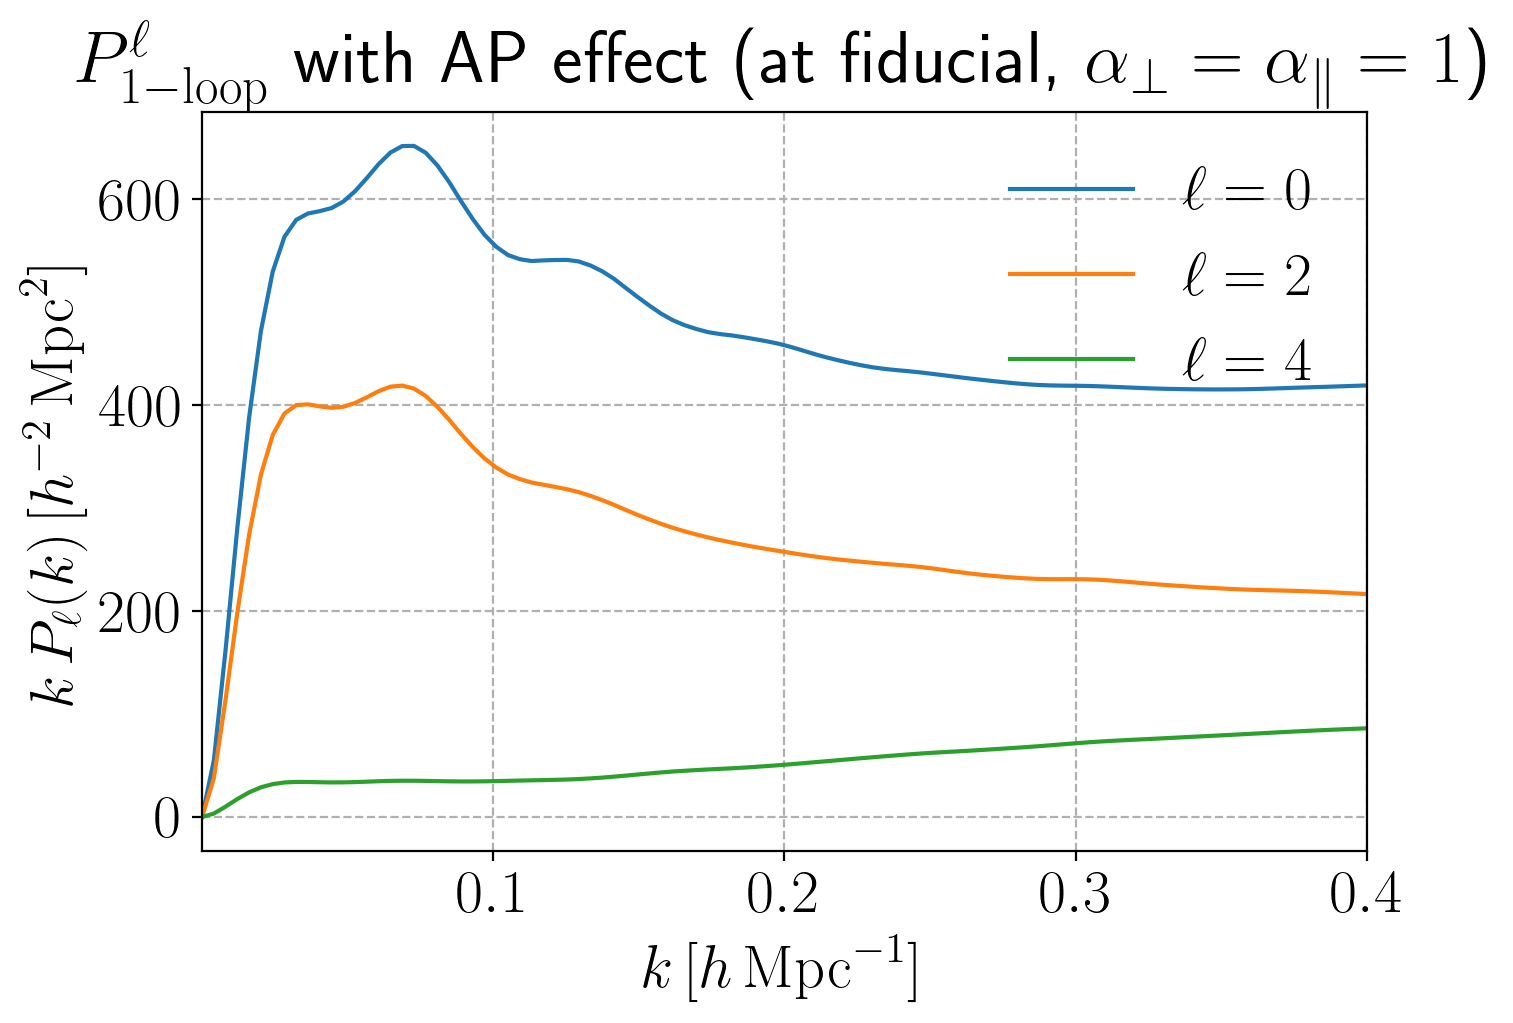

In [12]:
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
for l, ell in enumerate(ells_tuple):
    ax.plot(k_test, k_test * pk_ells_test[l], label=r'$\ell = %d$' % ell)
ax.set_xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$k \, P_{\ell}(k) \, [h^{-2} \, \mathrm{Mpc}^2]$')
ax.set_xlim(k_test.min(), k_test.max())
ax.legend(frameon=False)
ax.grid(linestyle='--')
ax.set_title(r'$P^\ell_{\rm 1-loop}$ with AP effect (at fiducial, $\alpha_\perp=\alpha_\parallel=1$)')

## Jacobian

In [13]:
k = jnp.linspace(5e-3, 0.25, 50)

%time jac = jax.jacfwd(jitted_wrapper, argnums=0)(packed_params, k=k)
print("Jacobian shape:", jac.shape)

CPU times: user 29.1 s, sys: 1.17 s, total: 30.3 s
Wall time: 10.8 s
Jacobian shape: (150, 22)


### Compare JAX autodiff vs finite differences

In [14]:
%time jac_nd = nd.Jacobian(lambda p: jitted_wrapper(p, k=k), step=2e-4)(packed_params)
print("Jacobian shape (nd):", jac_nd.shape)

CPU times: user 25.6 s, sys: 2.03 s, total: 27.7 s
Wall time: 6.42 s
Jacobian shape (nd): (150, 22)


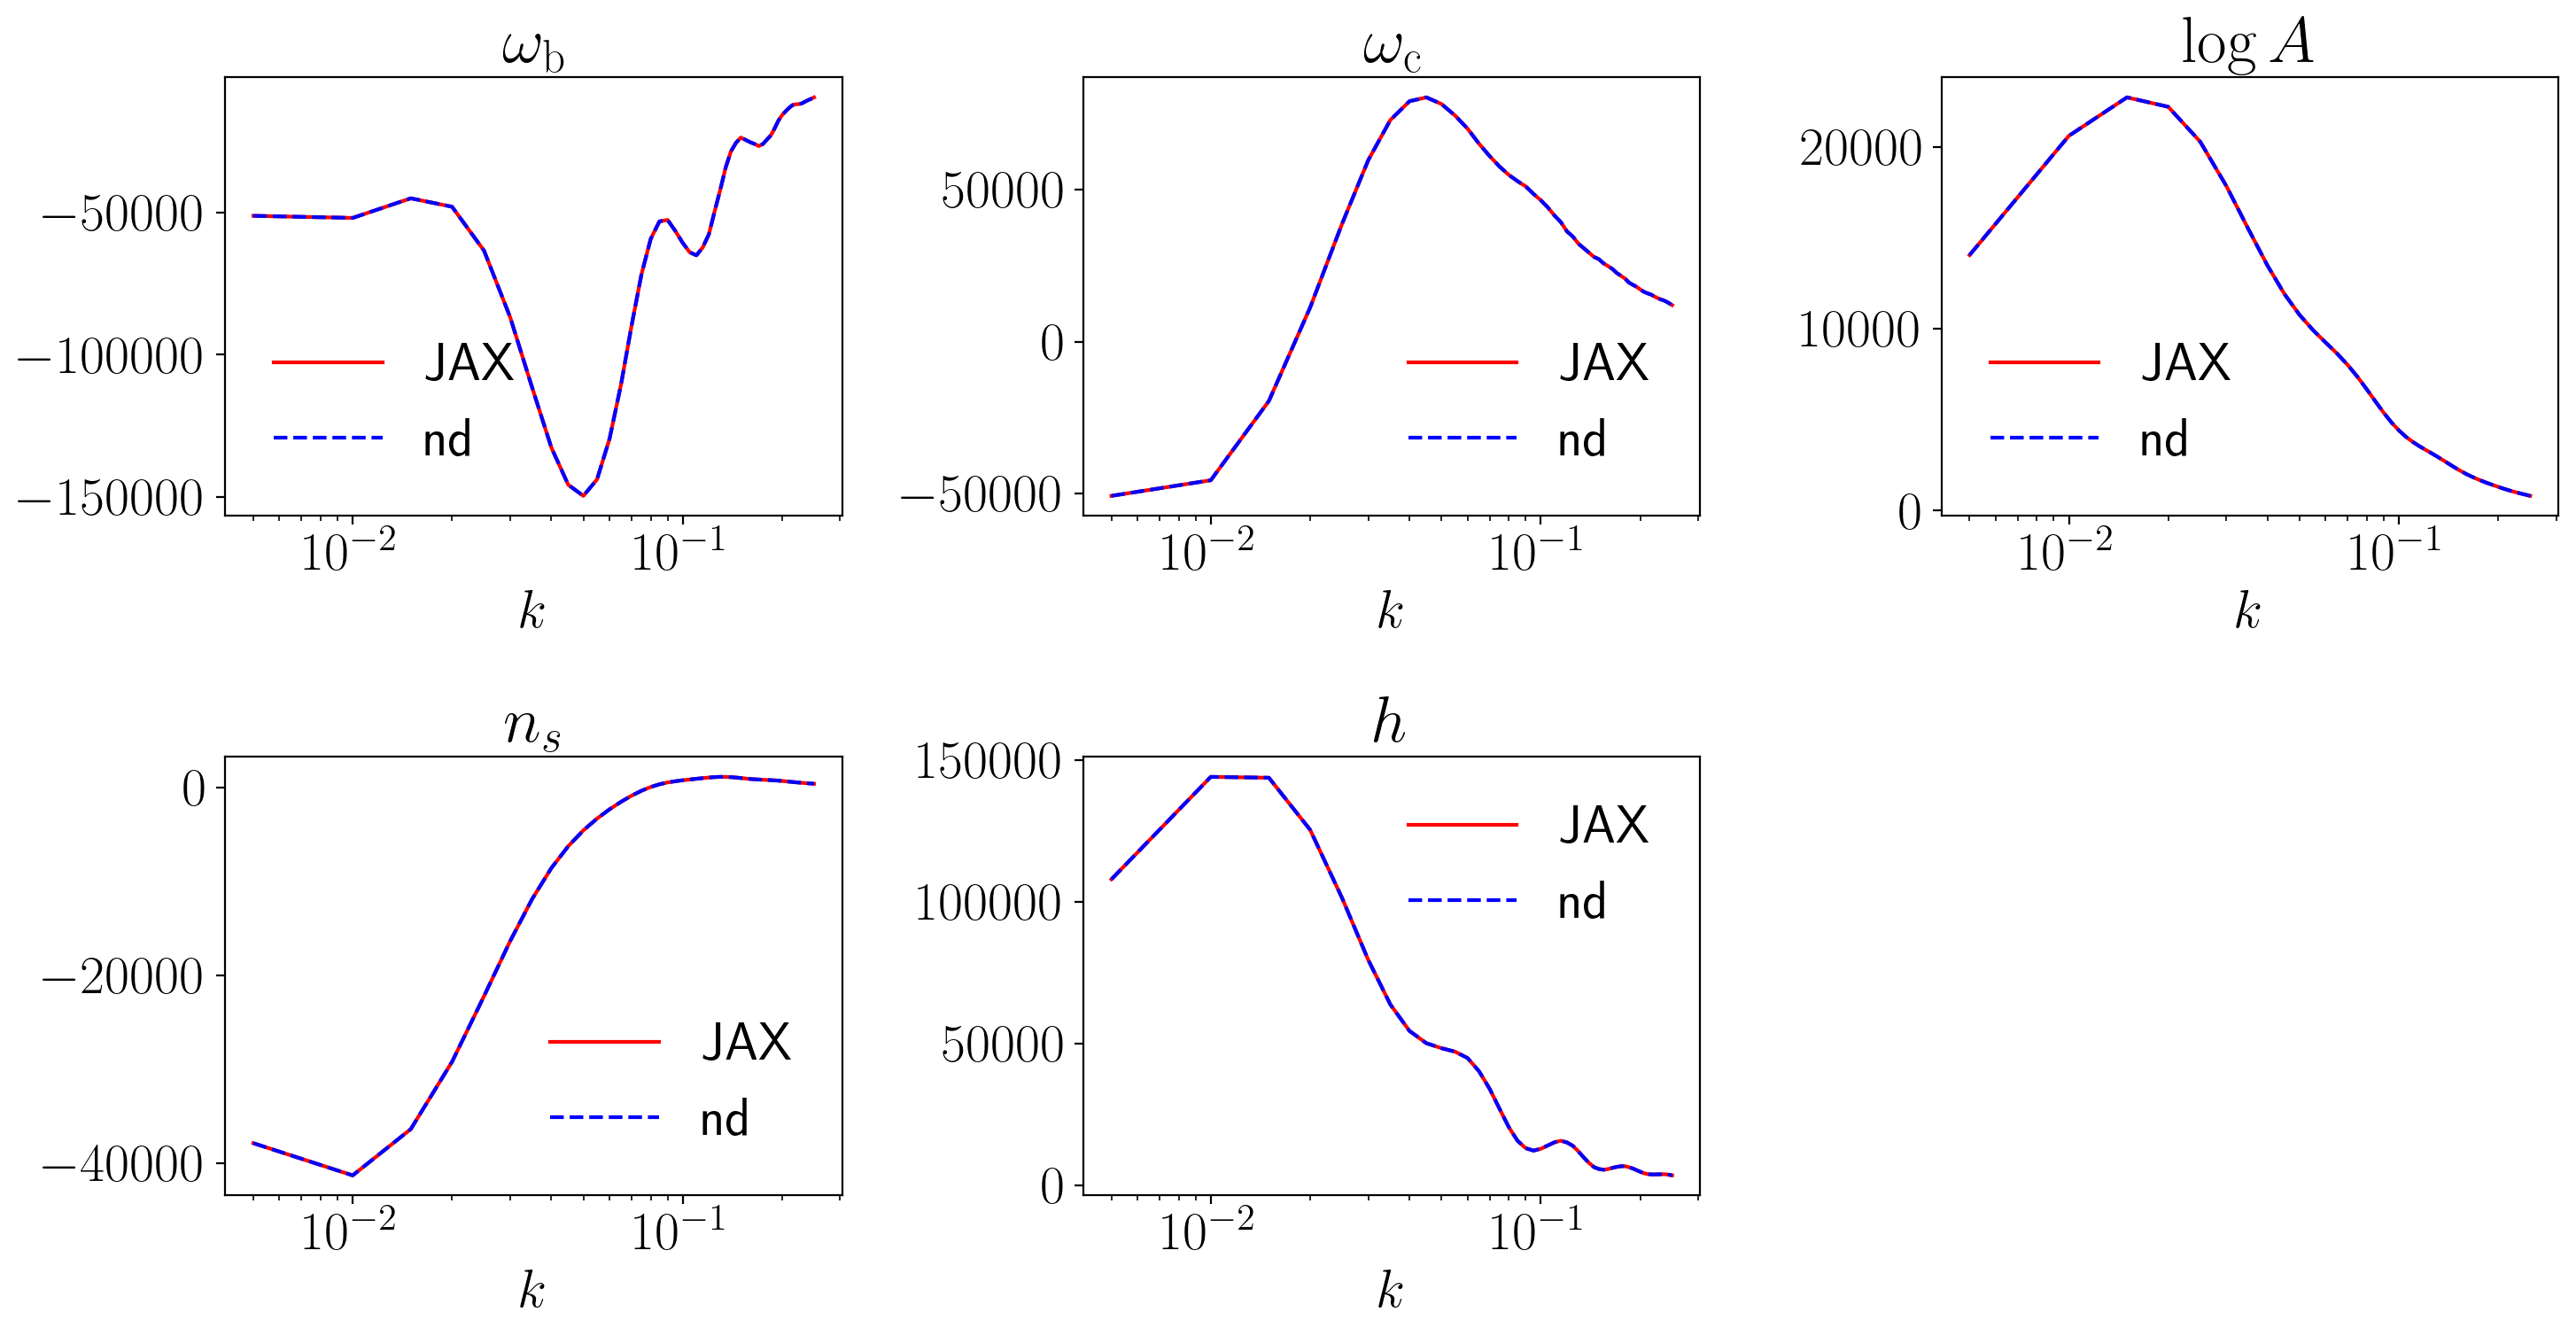

In [15]:
cosmo_labels = (r'$\omega_\mathrm{b}$', r'$\omega_\mathrm{c}$', r'$\log A$', r'$n_s$', r'$h$')
cosmo_idx    = [0, 1, 2, 3, 4]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
for idx, (i, j) in enumerate([(r, c) for r in range(2) for c in range(3)]):
    ax = axs[i, j]
    if idx >= len(cosmo_labels):
        ax.axis('off')
        continue
    ax.semilogx(k, jac[:k.shape[0], idx],    c='r',  label='JAX')
    ax.semilogx(k, jac_nd[:k.shape[0], idx], c='b', ls='--', label='nd')
    ax.set_title(cosmo_labels[idx])
    ax.set_xlabel(r'$k$')
    ax.legend(frameon=False)
plt.tight_layout()

## Gaussian covariance

In [16]:
# gaussian_covariance imported from jaxptpolypol.covariance

In [17]:
ps1loop_ells = jitted_wrapper(packed_params, k=k).reshape(len(ells_tuple), k.shape[0])
gauss_cov = gaussian_covariance(V, k, k[1]-k[0], *ps1loop_ells)
print("Covariance shape:", gauss_cov.shape)

Covariance shape: (150, 150)


## Fisher matrix

In [18]:
# fisher_matrix imported from jaxptpolypol.inference

fisher = fisher_matrix(gauss_cov, jac)
print("Fisher matrix shape:", fisher.shape)

Fisher matrix shape: (22, 22)


## Fisher contours

In [19]:
# plot_contours, plot_Gaussian imported from jaxptpolypol.plotting

Varied parameter indices: [0, 1, 2, 3, 4, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_46434/687700110.py:14: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.4, hspace=0.4)


Text(0.5, 0.98, '$P^{\\ell=[0,2,4]}_{\\rm with\\,AP}$ forecast (bin 1, $z_{\\rm eff}=0.7$)')

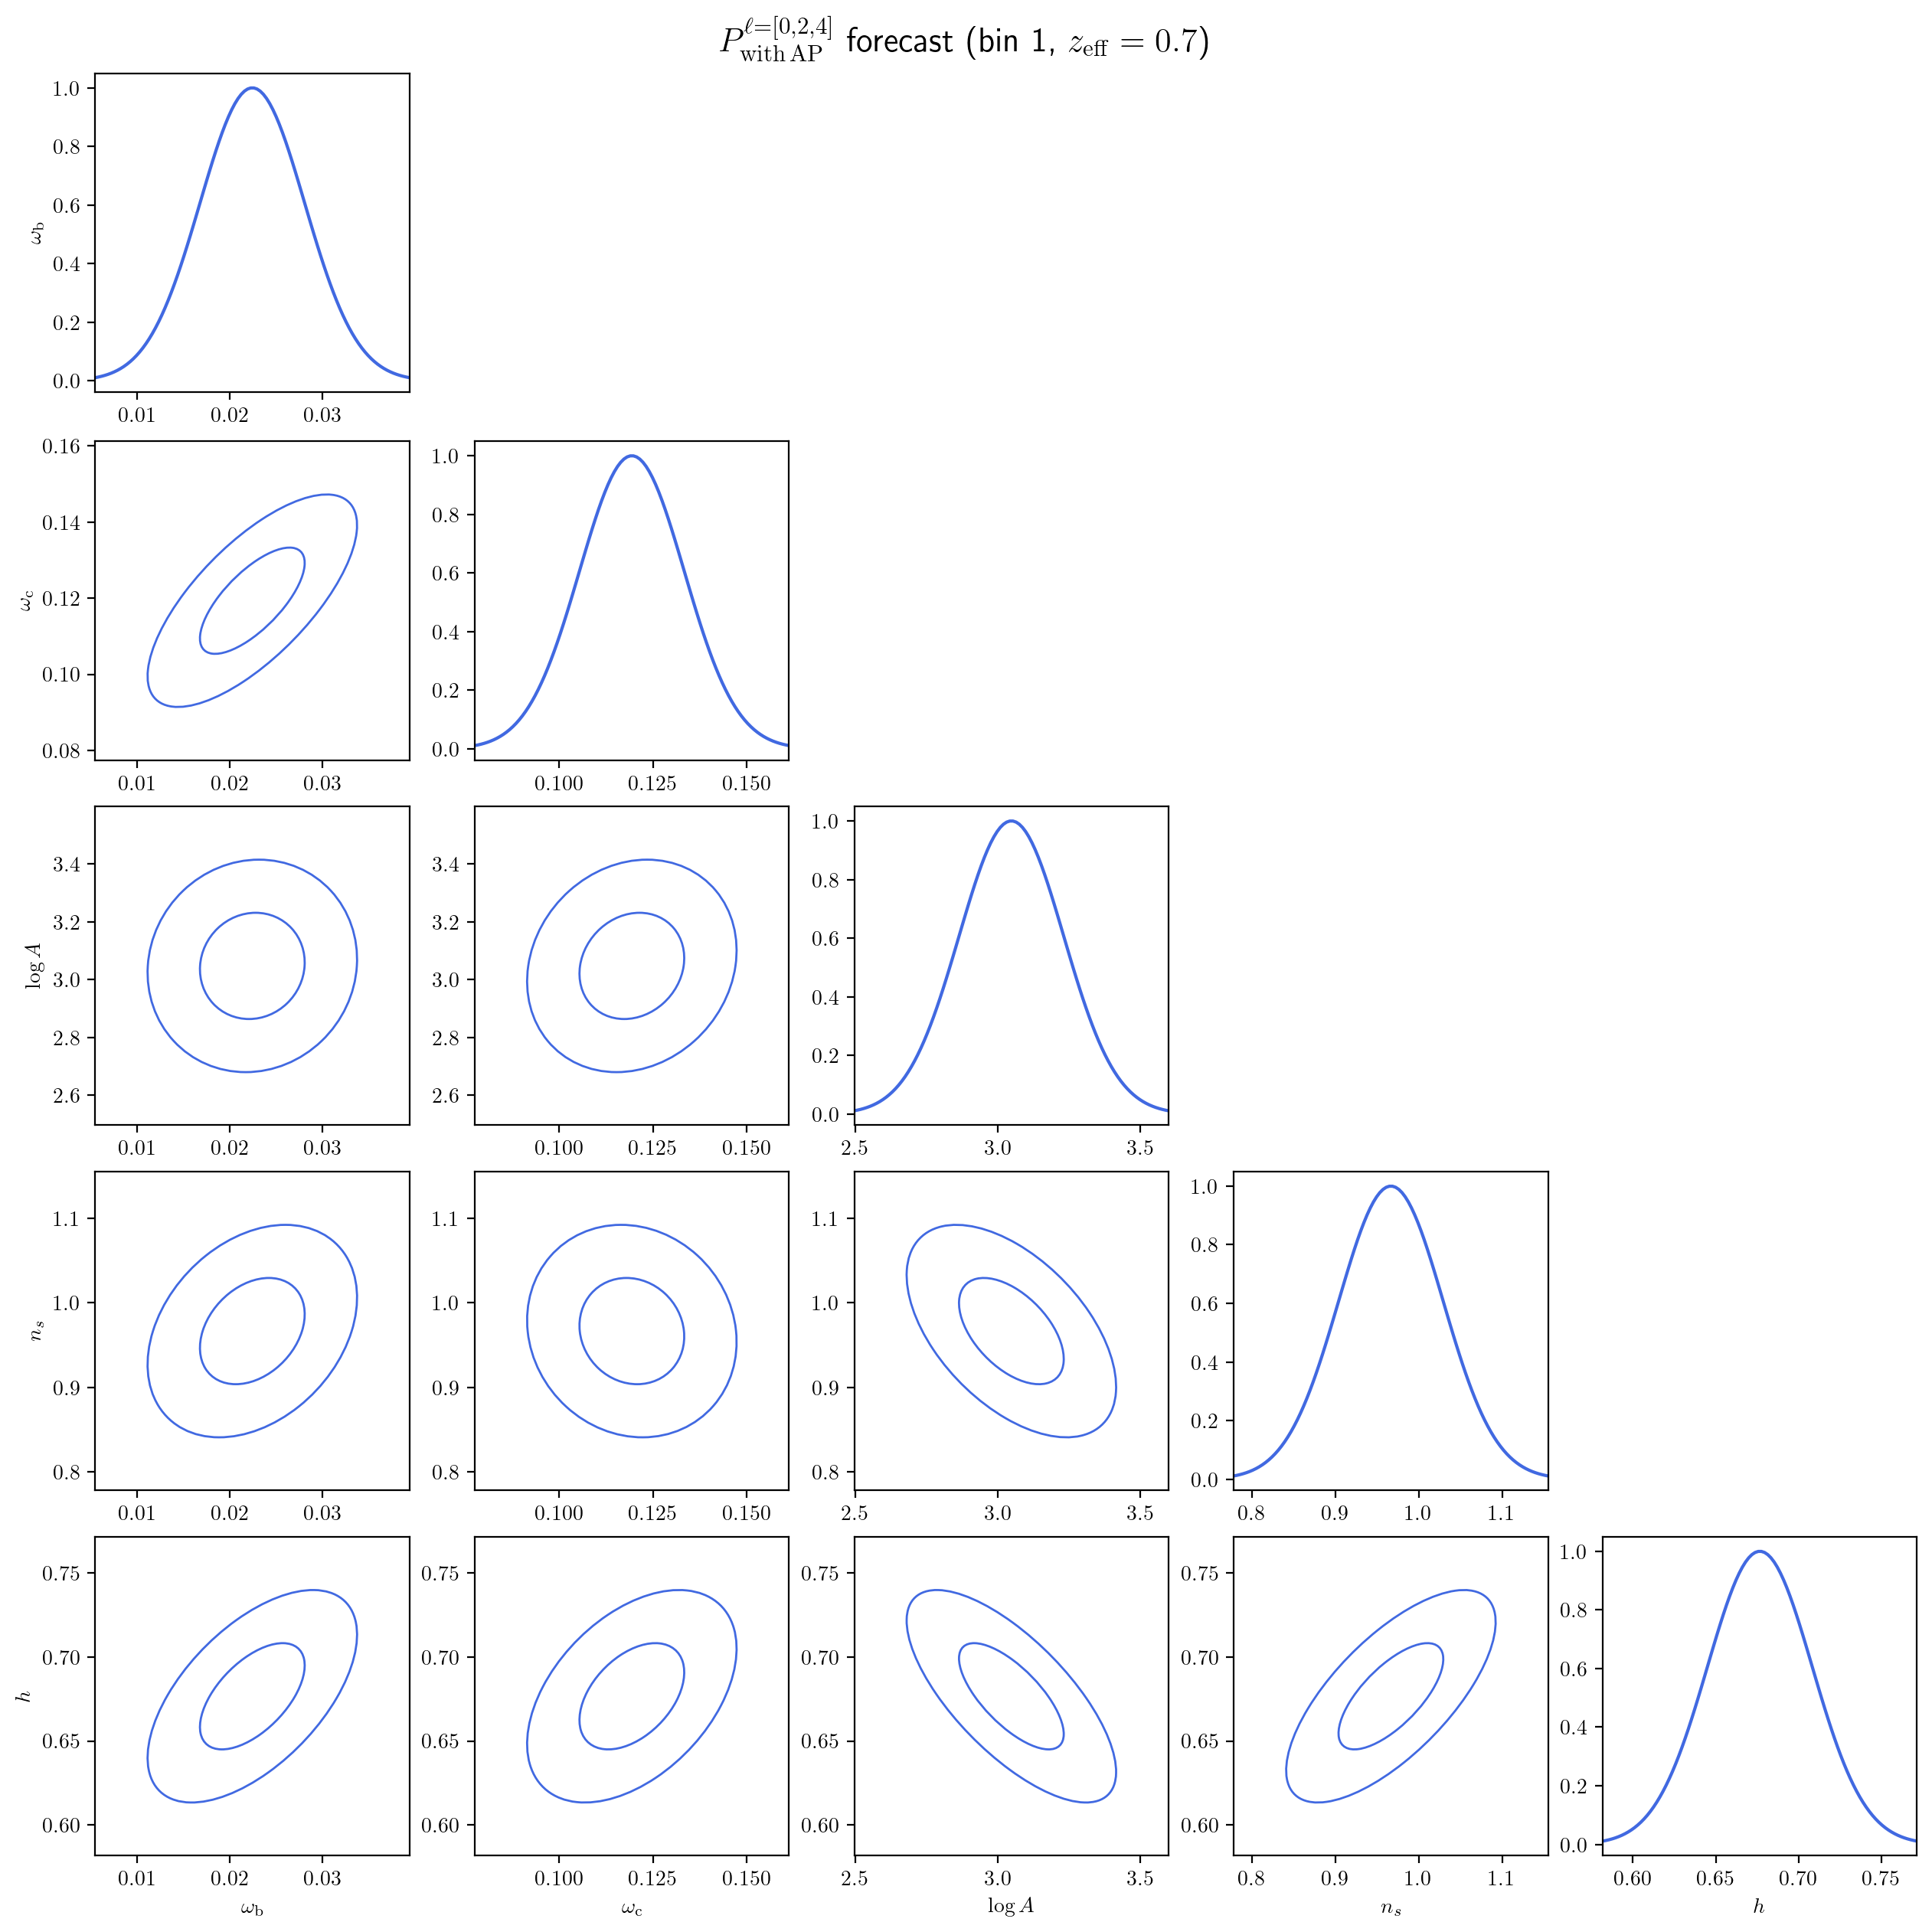

In [20]:
cosmo_param_names = (r'$\omega_\mathrm{b}$', r'$\omega_\mathrm{c}$', r'$\log A$', r'$n_s$', r'$h$')
n_cosmo_plot      = len(cosmo_param_names)
cosmo_plot_idx    = np.array([0, 1, 2, 3, 4])

all_idx = list(range(fisher.shape[0]))
fixed_survey_keys = {('shared', 'k_nl', None), ('shared', 'ndens', None)}
fixed_survey_offsets = [i for i, key in enumerate(pk_survey_keys) if key in fixed_survey_keys]
fixed_idx = [5, 6, 7, 8] + [len(cosmo.param_keys) + i for i in fixed_survey_offsets]
varied_idx = [i for i in all_idx if i not in fixed_idx]
print("Varied parameter indices:", varied_idx)

F_marg = fisher[np.ix_(varied_idx, varied_idx)]

plt.rcParams.update({"font.size": 10, "figure.constrained_layout.use": True})
fig = plt.figure(figsize=(n_cosmo_plot*2.5, n_cosmo_plot*2.5))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

for i in range(n_cosmo_plot):
    for j in range(n_cosmo_plot):
        ax = plt.subplot(n_cosmo_plot, n_cosmo_plot, i*n_cosmo_plot+j+1)
        if j < i:
            plot_contours(F_marg, packed_params[cosmo_plot_idx], np.array([j, i]),
                          fill=False, color='royalblue')
        elif j == i:
            plot_Gaussian(F_marg, packed_params[cosmo_plot_idx], i, color='royalblue')
        else:
            ax.axis('off')
        if i == n_cosmo_plot - 1:
            plt.xlabel(cosmo_param_names[j])
        if j == 0:
            plt.ylabel(cosmo_param_names[i])

fig.suptitle(r'$P^{\ell=[0,2,4]}_{\rm with\,AP}$ forecast (bin 1, $z_{\rm eff}=0.7$)', fontsize=16)
